# **Proyecto 2 - Parte II**

## **📌 Parto 0: Objetivo**

Realizar el preprocesamiento de datos y la optimización de modelos de machine learning para el conjunto de datos seleccionado. La meta es elegir la técnica de machine learning más adecuada y optimizar sus hiperparámetros para obtener el mejor rendimiento posible.

## **📌 Parte 1: Preprocesamiento de Datos:**

### 1.1  Cargar los Datos y librerias

- Importación  de las principales librerías que se podrían utilizar en el estudio.
- Carga del Dataframe

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

#Carga del dataframe
df=pd.read_csv(r'global-data-on-sustainable-energy.csv')

print(f'Dataset cargado exitosamente!')
print(f'='*50)
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'='*50)
print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.0f} KB')
print(f'='*50)
print(f'\nColumnas: {list(df.columns)}')

Dataset cargado exitosamente!
Dimensiones: 3649 filas x 21 columnas
Memoria aproximada: 930 KB

Columnas: ['Entity', 'Year', 'Access to electricity (% of population)', 'Access to clean fuels for cooking', 'Renewable-electricity-generating-capacity-per-capita', 'Financial flows to developing countries (US $)', 'Renewable energy share in the total final energy consumption (%)', 'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', 'Electricity from renewables (TWh)', 'Low-carbon electricity (% electricity)', 'Primary energy consumption per capita (kWh/person)', 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)', 'Value_co2_emissions_kt_by_country', 'Renewables (% equivalent primary energy)', 'gdp_growth', 'gdp_per_capita', 'Density\\n(P/Km2)', 'Land Area(Km2)', 'Latitude', 'Longitude']


### 1.2 Descripción de las variables y su distribución.

Contexto

>Conjunto de datos que muestra indicadores de energía sostenible y otros factores relevantes en todos los países desde 2000 hasta 2020. Los aspectos clave que se encuentran en este dataset son: acceso a la electricidad, las energías renovables, las emisiones de carbono, la intensidad energética, los flujos financieros y el crecimiento económico. EL objetivo es comparar países, realizar un seguimiento del progreso hacia el Objetivo de Desarrollo Sostenible 7 y obtener información valiosa sobre los patrones de consumo energético global a lo largo del tiempo.

---

Descripción de Datos

*Levantamiento de las variables, tipo de dato y descripción.*


| Columna | Tipo | Descripción |
| :--- | :--- | :--- |
| `Entity` | str | Nombre del país o región para la que se informan los datos.|
| `Year` | int | Año para el que se informan los datos, entre 2000 y 2020.|
| `Access to electricity (% of population)` | float | Porcentaje de la población con acceso a la electricidad.|
| `Access to clean fuels for cooking (% of population)` | float | Porcentaje de la población que depende principalmente de combustibles limpios.|
| `Renewable-electricity-generating-capacity-per-capita` | float | Capacidad instalada de energía renovable por persona.|
| `Financial flows to developing countries (US $)` | int | Ayuda y asistencia de países desarrollados para proyectos de energía limpia.|
| `Renewable energy share in total final energy consumption (%)` | float | Porcentaje de energía renovable en el consumo total de energía final.|
| `Electricity from fossil fuels (TWh)` | float | Electricidad generada a partir de combustibles fósiles (carbón, petróleo, gas) en teravatios-hora.|
| `Electricity from nuclear (TWh)` | float | Electricidad generada a partir de energía nuclear en teravatios-hora. |
| `Electricity from renewables (TWh)` | float | Electricidad generada a partir de fuentes renovables (hidroeléctrica, solar, eólica, etc.) en teravatios-hora.|
| `Low-carbon electricity (% electricity)` | float | Porcentaje de electricidad procedente de fuentes bajas en carbono (nuclear y renovables).|
| `Primary energy consumption per capita (kWh/person)` | float | Consumo de energía por persona en kilovatios-hora.|
| `Energy intensity level of primary energy (MJ/$2011 PPP GDP)` | float | Uso de energía por unidad de PIB en paridad de poder adquisitivo.|
| `Value_co2_emissions (metric tons per capita)` | float | Emisiones de dióxido de carbono por persona en toneladas métricas.|
| `Renewables (% equivalent primary energy)` | float | Energía primaria equivalente derivada de fuentes renovables.|
| `GDP growth (annual %)` | float | Tasa de crecimiento anual del PIB basada en moneda local constante.|
| `GDP per capita` | float | Producto interno bruto per cápita.|
| `Density (P/Km2)` | int | Densidad de población en personas por kilómetro cuadrado.|
| `Land Area (Km2)` | int | Superficie terrestre total en kilómetros cuadrados.|
| `Latitude` | float| Latitud del centroide del país en grados decimales.|
| `Longitude` | float | Longitud del centroide del país en grados decimales.|





Generando histogramas...


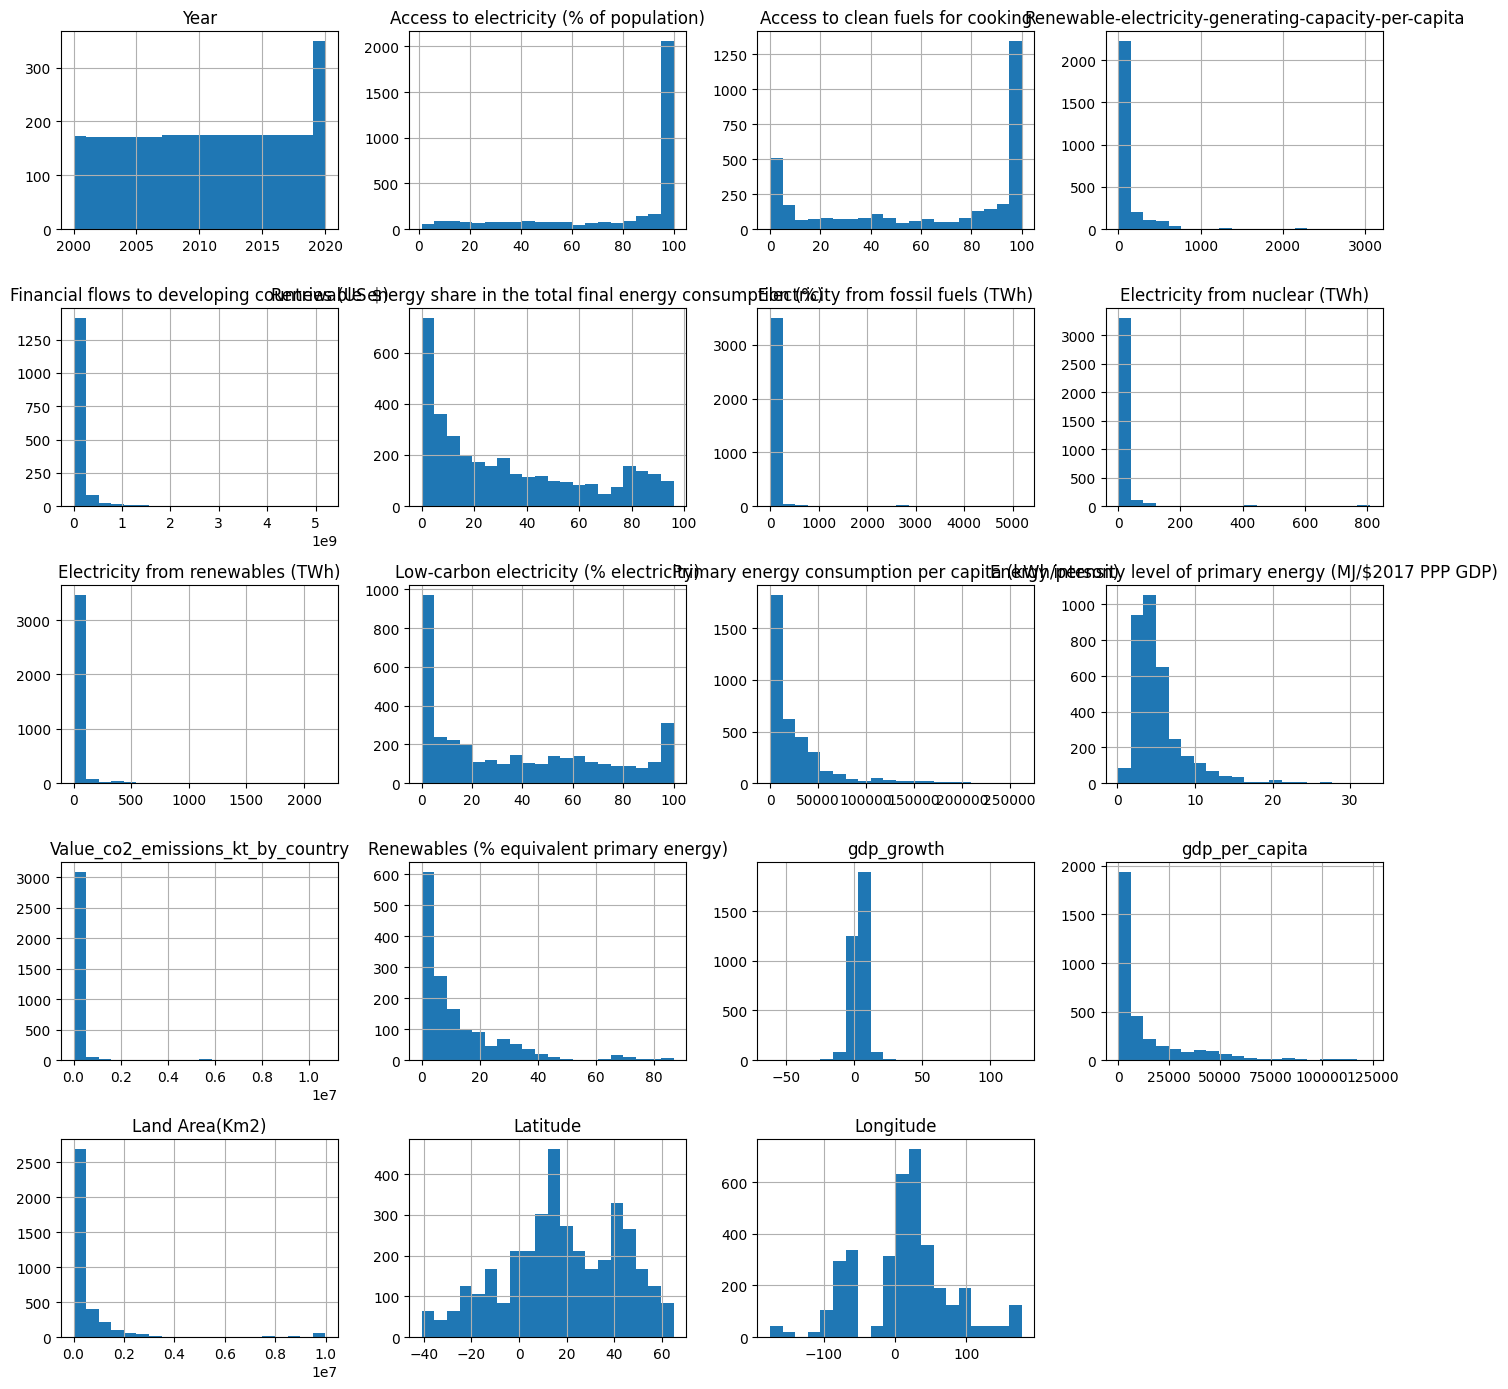

In [2]:
# Gráficos distribución de las variables

df_dist = df.drop(columns=[])
num_cols = df_dist.select_dtypes(include=["number"]).columns

if len(num_cols) > 0:
    print("\nGenerando histogramas...")
    df_dist[num_cols].hist(bins=20, figsize=(14, 14), layout=(-1, 4))
    plt.tight_layout()
    plt.show()

Análisis de Gráficos de Distribución

---

🔍 Principales Comentarios

* `Access_to_Electricity_pu` y `Access_to_clean_fuels_for_cooking_pu`: Se observa una distribución sesgada hacia valores altos (Sesgo Negativo; Cola a la izquierda), indicando que una gran proporción de países tienen altos niveles de acceso, mientras que un grupo menor tienen un acceso limitado.

* `gdp_pc`, `Financial_flows_to_developing_countries_usd`: Distribuciones con Sesgo Positivo (Cola a la derecha), esto significa que la mayoría de los países tienen valores más bajos, y un pequeño número de países muy ricos o con grandes flujos financieros impulsan la cola derecha de la distribución.

* `Electricity_from_fossil_fuels_TWh`, `Electricity_from_nuclear_TWh`, `Electricity_from_renewables_TWh`, `Primary_energy_consumption_pc_kWhp` y `Value_co2_emissions_kt_by_country`: Al igual que las variables económicas, estas también tienden a ser asimétricas a la derecha, con muchos países con bajo consumo/producción/emisiones y unos pocos grandes productores/emisores dominando los valores más altos.

* `Renewable_electricity_generating_capacity_pc`, `Renewable_energy_in_total_consumption_pu`, `Renewables_pu_equivalent_primary_energy`: Estas pueden mostrar una variedad de distribuciones. Algunos países pueden tener un porcentaje bajo o nulo de energías renovables, mientras que otros están muy avanzados. Es posible ver una distribución bimodal o una asimetría a la izquierda o derecha dependiendo del indicador.

* `Year`: Dado que el dataset cubre años consecutivos (2000-2020), la distribución de esta variable debería ser aproximadamente uniforme, con una cantidad similar de registros por cada año. Sin embargo, el año 2020 presenta una mayor frecuencia, lo cual se puede deber a que ese año se agregaron paises, o no hay datos para alguno paises para años anteriores al 2020.

* `Latitude` y `Longitude`: Tienen una distribución similar simetirca, con algunas diferencias menores.

---



💬 Conclusiones Generales


>El análisis visual de estas distribuciones es fundamental para identificar si existen valores atípicos que puedan sesgar los modelos y para entender mejor el rango y la concentración de los datos en cada variable.



Información de los datos

*   **Exploración de datos:** Se realiza la exploración de datos, con la finalidad de revisar como quedo el nuevo DataFrame limpio.
*   **Comando `df.head(10)`:** Permite mostrar las primeras 10 filas. Se observa varias columna con valores nulos.
*   **Comando `df.tail(5)`:** Mostramos las últimas 5 filas. Se observan varias columnas con valores nulos.
*   **Comando `df.info()`:** Mostramos la informacinón general del DataFrame entre ellas:
    *   **Número de entradas:** 3649 entradas.
    *   **Nombres de columnas:** 8 columnas desde `Entity` hasta `Longitude`.
    *   **Tipo de datos:**18 columnas son float y 1 columnas son int y 2 columnas str.
    *   **Memoria utilizada:** 598.8 KB
    *   No se observan grandes problemas con la data.
*   **Datos estadísticos:** Además, se muestras datos estadísticos asociado a datos numéricos y categoricos. En el caso de la variable `Density (P/Km2)` se muestra como categórica, lo cual ocurre por que tiene valores como dentro de sus datos.


In [3]:
#Se muestran filas y columnas
print("Se presentan filas y columnas")
print("="*80)
print(df.shape)
print("-"*80)

#Se muestran las primeras 10 filas del DataFrame
print("Se presentan las primeras 10 filas")
print("="*80)
print(df.head(10))
print("-"*80)

#Se muestran las últimas 5 filas del DataFrame
print("Se presenta las últimas 5 filas")
print("="*80)
print(df.tail(5))
print("-"*80)

#Información general del DataFrame
print("Se presenta información general del DataFrame")
print("="*80)
print(df.info())
print("-"*80)

#Estadísticas descriptivas de columnas numéricas y de categoría
print("Se presentan estadísticas descriptivas del DataFrame")
print('='*40+'Columnas numericas'*1+'='*40)
display(df.describe().round(2))
print(" "*80)
print('='*40+'Columnas categoricas'*1+'='*40)
display(df.describe(include='str'))

Se presentan filas y columnas
(3649, 21)
--------------------------------------------------------------------------------
Se presentan las primeras 10 filas
        Entity  Year  Access to electricity (% of population)  \
0  Afghanistan  2000                                 1.613591   
1  Afghanistan  2001                                 4.074574   
2  Afghanistan  2002                                 9.409158   
3  Afghanistan  2003                                14.738506   
4  Afghanistan  2004                                20.064968   
5  Afghanistan  2005                                25.390894   
6  Afghanistan  2006                                30.718690   
7  Afghanistan  2007                                36.051010   
8  Afghanistan  2008                                42.400000   
9  Afghanistan  2009                                46.740050   

   Access to clean fuels for cooking  \
0                               6.20   
1                               7.20   
2      

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
count,3649.00,3639.00,3480.00,2718.00,1.560000e+03,3455.00,3628.00,3523.00,3628.00,3607.00,3649.00,3442.00,3221.00,1512.00,3332.00,3367.00,3648.00,3648.00,3648.00
mean,2010.04,78.93,63.26,113.14,9.422400e+07,32.64,70.37,13.45,23.97,36.80,25743.98,5.31,159866.46,11.99,3.44,13283.77,633213.49,18.25,14.82
std,6.05,30.28,39.04,244.17,2.981544e+08,29.89,348.05,73.01,104.43,34.31,34773.22,3.53,773661.06,14.99,5.69,19709.87,1585519.22,24.16,66.35
min,2000.00,1.25,0.00,0.00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00,0.11,10.00,0.00,-62.08,111.93,21.00,-40.90,-175.20
25%,2005.00,59.80,23.18,3.54,2.600000e+05,6.52,0.29,0.00,0.04,2.88,3116.74,3.17,2020.00,2.14,1.38,1337.81,25713.00,3.20,-11.78
50%,2010.00,98.36,83.15,32.91,5.665000e+06,23.30,2.97,0.00,1.47,27.87,13120.57,4.30,10500.00,6.29,3.56,4578.63,117600.00,17.19,19.15
75%,2015.00,100.00,100.00,112.21,5.534750e+07,55.24,26.84,0.00,9.60,64.40,33892.78,6.03,60580.00,16.84,5.83,15768.62,513120.00,38.97,46.20
max,2020.00,100.00,100.00,3060.19,5.202310e+09,96.04,5184.13,809.41,2184.94,100.00,262585.70,32.57,10707219.73,86.84,123.14,123514.20,9984670.00,64.96,178.07


                                                                                
========================================Columnas categoricas========================================


,Entity,Density\n(P/Km2)
count,3649,3648
unique,176,124
top,Afghanistan,25
freq,21,147


### 1.3 Limpieza de Datos:

#### a) Revisión  y corrección de data

---

*   Reemplzado de nombres de columnas, con la finalidad de estadarizar el texto y reducir el largo de ellos.

*   Eliminación del valor coma (,) en los datos de la variables 'Density_n_P_km2'. Posteriormente se convierte a numérica.

---

In [4]:
# Reemplazar todos los nombres de columnas a la vez, para simplicidad de lectura
df.columns = ['Country', 'Year', 'Access_to_Electricity_pu', 'Access_to_clean_fuels_for_cooking_pu', 'Renewable_electricity_generating_capacity_pc', 'Financial_flows_to_developing_countries_usd', 'Renewable_energy_in_total_consumption_pu', 'Electricity_from_fossil_fuels_TWh', 'Electricity_from_nuclear_TWh', 'Electricity_from_renewables_TWh', 'Low_carbon_electricity_pu_electricity', 'Primary_energy_consumption_pc_kWhp','Energy_intensity_level_of_primary_energy_MJ_$2017_ppp_GDP', 'Value_co2_emissions_kt_by_country', 'Renewables_pu_equivalent_primary_energy', 'gdp_growth', 'gdp_pc', 'Density_n_P_km2', 'Land_Area_km2', 'Latitude','Longitude']

In [5]:
# Modificación de la variable 'Density_n_P_km2'.

# Reemplazo de texto para estandarizar en variable 'Density_n_P_km2'

df['Density_n_P_km2'] = df['Density_n_P_km2'].str.replace(',', '', regex=False)

# Convertir la columna 'Density_n_P_km2' a numérico
df['Density_n_P_km2'] = pd.to_numeric(df['Density_n_P_km2'])


In [6]:
# Eliminar columna "Country".

#df = df.drop(columns=["Country"])

#### b) Identificación de datos duplicados.

In [7]:
# Revisión de duplicados
print('Proceso de eliminar filas duplicadas')
print("="*80)
print(" "*80)
print(f'Filas antes de eliminar duplicados: {len(df)}')
print("-"*80)

n_total = len(df)
n_dupes = df.duplicated().sum()

if not n_dupes:
    print('Datos duplicados: No se encontraron filas duplicadas')
    print("-"*80)
else:

    print(f'Filas totales:           {n_total}')
    print(f'Duplicados exactos:      {n_dupes} ({n_dupes/n_total*100:.3f}%)')
    print("-"*80)
    # Eliminamos duplicados exactos.
    df = df.drop_duplicates()
    print(f'Filas despues de eliminar duplicados: {len(df)}')
    print("="*80)


Proceso de eliminar filas duplicadas
                                                                                
Filas antes de eliminar duplicados: 3649
--------------------------------------------------------------------------------
Datos duplicados: No se encontraron filas duplicadas
--------------------------------------------------------------------------------


#### c) Identificación de datos nulos

In [8]:
# Codigo para revisar nulos

null_report = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)


if null_report.empty:
    print()
    print("="*60)
    print('Datos nulos: No se encontraron valores nulos')
    print("="*60)
else:
    print()
    print("="*60)
    print('Datos nulos: Columnas con valores nulos y recomendaciones')
    print("-"*60)
    display(null_report)
    print("="*60)


Datos nulos: Columnas con valores nulos y recomendaciones
------------------------------------------------------------


,Nulos,Porcentaje,Umbral
Renewables_pu_equivalent_primary_energy,2137,58.56,Eliminar columna (> 50%)
Financial_flows_to_developing_countries_usd,2089,57.25,Eliminar columna (> 50%)
Renewable_electricity_generating_capacity_pc,931,25.51,Imputar (< 30%)
Value_co2_emissions_kt_by_country,428,11.73,Imputar (< 30%)
gdp_growth,317,8.69,Imputar (< 30%)
gdp_pc,282,7.73,Imputar (< 30%)
Energy_intensity_level_of_primary_energy_MJ_$2017_ppp_GDP,207,5.67,Imputar (< 30%)
Renewable_energy_in_total_consumption_pu,194,5.32,Imputar (< 30%)
Access_to_clean_fuels_for_cooking_pu,169,4.63,Imputar (< 30%)
Electricity_from_nuclear_TWh,126,3.45,Imputar (< 30%)


 🌡️Tratamiento de valores nulos.

---

*   `Value_co2_emissions_kt_by_country` (Target):  Elinamos filas con nulos de variable objetivo, con la finalidad de no inventar lo que se debe predecir o usar para predecir.

*   `Access_to_Electricity_pu`: Interpolación de datos faltantes para cada pais por separado.

*   `Electricity_from_fossil_fuels_TWh`, `Electricity_from_nuclear_TWh`, `Electricity_from_renewables_TWh`,`Low_carbon_electricity_pu_electricity`: Eliminamos todas las filas con nulos en estas variables, ya que, son variables relevantes para predecir la variable objetivo.

*   `Access_to_clean_fuels_for_cooking_pu`, `Renewable_energy_in_total_consumption_pu`, `Energy_intensity_level_of_primary_energy_MJ_$2017_ppp_GDP`, `Renewable_electricity_generating_capacity_pc` y `Renewables_pu_equivalent_primary_energy`: Reconstuimos las valores nulos de acuerdo al año y pais cercano a cada pais que tiene nulos.

*   `gdp_pc` y `gdp_growth`: Relleno de valores nulos con interpolación, solo los paises que tienen nulos intermedios. Los que tienen nulos completos no se consideran.

*   `Financial_flows_to_developing_countries_usd`: Reconstruimos nulos interpolando dentro de cada pais y con paises cercanos. Los paises desarrollados se dejan en cero, ya que ellos prestan ayuda y no reciben.

---

In [9]:
#Eliminar datos nulos de variables 'target'


# Elimina filas donde 'Value_co2_emissions_kt_by_country' es nulo
df = df.dropna(subset=['Value_co2_emissions_kt_by_country'])


In [10]:
# Interpola y asegura el llenado de los nulos en los extremos
df['Access_to_Electricity_pu'] = (df.groupby('Country')['Access_to_Electricity_pu']
                          .transform(lambda x: x.interpolate().ffill().bfill()))

In [11]:
#Eliminar filas nulos:

df = df.dropna(subset=['Electricity_from_fossil_fuels_TWh', 'Electricity_from_nuclear_TWh', 'Electricity_from_renewables_TWh','Low_carbon_electricity_pu_electricity'])

In [12]:
# Lista de variables a trabajar.
columnas_energia = [
    'Access_to_clean_fuels_for_cooking_pu',
    'Renewable_energy_in_total_consumption_pu',
    'Energy_intensity_level_of_primary_energy_MJ_$2017_ppp_GDP',
    'Renewable_electricity_generating_capacity_pc',
    'Renewables_pu_equivalent_primary_energy'  # <-- Añadimos tu nueva variable aquí
]

# Ordenamos el DataFrame por 'Country' y 'Year' para asegurar que los datos estén organizados cronológicamente por país
df = df.sort_values(by=['Country', 'Year'])


# Relleno geográfico KNN (Para países sin ningún dato)
df_limpio_list = []

for year, group in df.groupby('Year'):
    # Añadimos las coordenadas a la lista de columnas que procesará el algoritmo
    columnas_knn = ['Latitude', 'Longitude'] + columnas_energia
    
    # n_neighbors=3 calculará el promedio de los 3 países vecinos más cercanos en el mapa
    imputer = KNNImputer(n_neighbors=3)
    
    # Validamos que el año tenga datos suficientes para entrenar el modelo
    if group[columnas_energia].notna().any().any():
        group[columnas_knn] = imputer.fit_transform(group[columnas_knn])
        
    df_limpio_list.append(group)

# Reconstruimos el DataFrame final completamente limpio
df = pd.concat(df_limpio_list, ignore_index=True)

# Ordenamos el DataFrame por 'Country' y 'Year' para asegurar que los datos estén organizados cronológicamente por país
df = df.sort_values(by=['Country', 'Year'])

In [13]:
# Variables a trabajar
variables_economicas = ['gdp_pc', 'gdp_growth']

for col in variables_economicas:

    # Identifica si hay algún país que no tenga historial de esta variable
    paises_vacios = df.groupby('Country')[col].apply(lambda x: x.isna().all())
    lista_a_eliminar = paises_vacios[paises_vacios].index
    
    # Borramos ese país completo si no aporta información económica
    df = df[~df['Country'].isin(lista_a_eliminar)].copy()
    
    # Conecta los años faltantes entre registros válidos del mismo país
    df[col] = df.groupby('Country')[col].transform(lambda x: x.interpolate(method='linear'))
    
    # si el país arranca sus primeros años con nulos,
    # busca el primer año real y lo arrastra hacia atrás (y viceversa al final)
    df[col] = df.groupby('Country')[col].transform(lambda x: x.ffill().bfill())

In [14]:
# Variable a procesar
col_financiera = 'Financial_flows_to_developing_countries_usd'

# Ordenar el DataFrame por 'Country' y 'Year' para asegurar que los datos estén organizados cronológicamente por país
df = df.sort_values(by=['Country', 'Year'])

# Paises desarrollados (No reciben ayuda financiera, por lo que se les asignará 0 en esa variable)
paises_desarrollados = [
    'Australia', 'Austria', 'Belarus', 'Belgium', 'Canada', 'Croatia', 
    'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 
    'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 
    'Japan', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 
    'New Zealand', 'Norway', 'Portugal', 'Romania', 'Singapore', 
    'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 
    'United Arab Emirates', 'United Kingdom', 'United States'
]

filtro_desarrollados = df['Country'].isin(paises_desarrollados)
df.loc[filtro_desarrollados, col_financiera] = df.loc[filtro_desarrollados, col_financiera].fillna(0)

# Conecta los años faltantes intermedios dentro del historial de cada país
df[col_financiera] = df.groupby('Country')[col_financiera].transform(lambda x: x.interpolate(method='linear'))

# Si faltan los primeros o últimos años de un país en desarrollo, arrastra el dato válido más cercano
df[col_financiera] = df.groupby('Country')[col_financiera].transform(lambda x: x.ffill().bfill())

# Si un país receptor no tiene ningún registro, promedia el financiamiento de sus 3 vecinos más cercanos en ese año
df_limpio_list = []

for year, group in df.groupby('Year'):
    columnas_knn = ['Latitude', 'Longitude', col_financiera]
    imputer = KNNImputer(n_neighbors=3)
    
    # Validamos que el año tenga datos suficientes de otros países para entrenar al vecino cercano
    if group[col_financiera].notna().any():
        group[columnas_knn] = imputer.fit_transform(group[columnas_knn])
        
    df_limpio_list.append(group)

# Reconstruimos el DataFrame final perfectamente limpio
df = pd.concat(df_limpio_list, ignore_index=True)


In [15]:
# Codigo para revisar nulos

null_report = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)


if null_report.empty:
    print()
    print("="*60)
    print('Datos nulos: No se encontraron valores nulos')
    print("="*60)
else:
    print()
    print("="*60)
    print('Datos nulos: Columnas con valores nulos y recomendaciones')
    print("-"*60)
    display(null_report)
    print("="*60)


Datos nulos: No se encontraron valores nulos


#### d) Identificar y eliminar outliers

In [16]:
# Outliers
print('=== ANALISIS DE OUTLIERS ===')
print()

# Convertir a una lista de Python
columnas = df.select_dtypes(include='number')

# Revisamos cada columna para detectar outliers usando el método IQR
for col in columnas:
    # Usamos IQR para detectar extremos
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_col = q3 + 1.5 * iqr

    # Filtramos los outliers
    outliers_col = df[df[col] > lim_col]

    # Imprimimos los resultados
    print(f'\nVariable: {col.upper()}')
    print(f' Q1={q1:.0f} Q3={q3:.0f} IQR={iqr:.0f} Limite IQR={lim_col:.0f}')
    print(f' Calidad del vino con {col.capitalize()} > limite IQR: {len(outliers_col)} ({len(outliers_col)/len(df)*100:.1f}%)')


=== ANALISIS DE OUTLIERS ===


Variable: YEAR
 Q1=2005 Q3=2014 IQR=9 Limite IQR=2028
 Calidad del vino con Year > limite IQR: 0 (0.0%)

Variable: ACCESS_TO_ELECTRICITY_PU
 Q1=54 Q3=100 IQR=46 Limite IQR=169
 Calidad del vino con Access_to_electricity_pu > limite IQR: 0 (0.0%)

Variable: ACCESS_TO_CLEAN_FUELS_FOR_COOKING_PU
 Q1=22 Q3=100 IQR=78 Limite IQR=217
 Calidad del vino con Access_to_clean_fuels_for_cooking_pu > limite IQR: 0 (0.0%)

Variable: RENEWABLE_ELECTRICITY_GENERATING_CAPACITY_PC
 Q1=7 Q3=130 IQR=123 Limite IQR=315
 Calidad del vino con Renewable_electricity_generating_capacity_pc > limite IQR: 293 (9.6%)

Variable: FINANCIAL_FLOWS_TO_DEVELOPING_COUNTRIES_USD
 Q1=0 Q3=12311250 IQR=12311250 Limite IQR=30778125
 Calidad del vino con Financial_flows_to_developing_countries_usd > limite IQR: 558 (18.2%)

Variable: RENEWABLE_ENERGY_IN_TOTAL_CONSUMPTION_PU
 Q1=8 Q3=60 IQR=51 Limite IQR=136
 Calidad del vino con Renewable_energy_in_total_consumption_pu > limite IQR: 0 (0.0%)

Va

📈 Análisis de Datos Outliers

---

Se mantienen los outliers para no perder información relevante, pero se podrían eliminar o imputar dependiendo del caso de uso y del modelo a utilizar.

---


### 1.5 Selección de caracteristicas importantes

#### a) Análisis de correlación entre variables

Matriz de correlación:
                                                    Year  \
Year                                                1.00   
Access_to_Electricity_pu                            0.13   
Access_to_clean_fuels_for_cooking_pu                0.06   
Renewable_electricity_generating_capacity_pc        0.13   
Financial_flows_to_developing_countries_usd         0.14   
Renewable_energy_in_total_consumption_pu           -0.03   
Electricity_from_fossil_fuels_TWh                   0.03   
Electricity_from_nuclear_TWh                       -0.00   
Electricity_from_renewables_TWh                     0.07   
Low_carbon_electricity_pu_electricity               0.03   
Primary_energy_consumption_pc_kWhp                  0.00   
Energy_intensity_level_of_primary_energy_MJ_$20... -0.17   
Value_co2_emissions_kt_by_country                   0.02   
Renewables_pu_equivalent_primary_energy             0.09   
gdp_growth                                         -0.09   
gdp_pc           

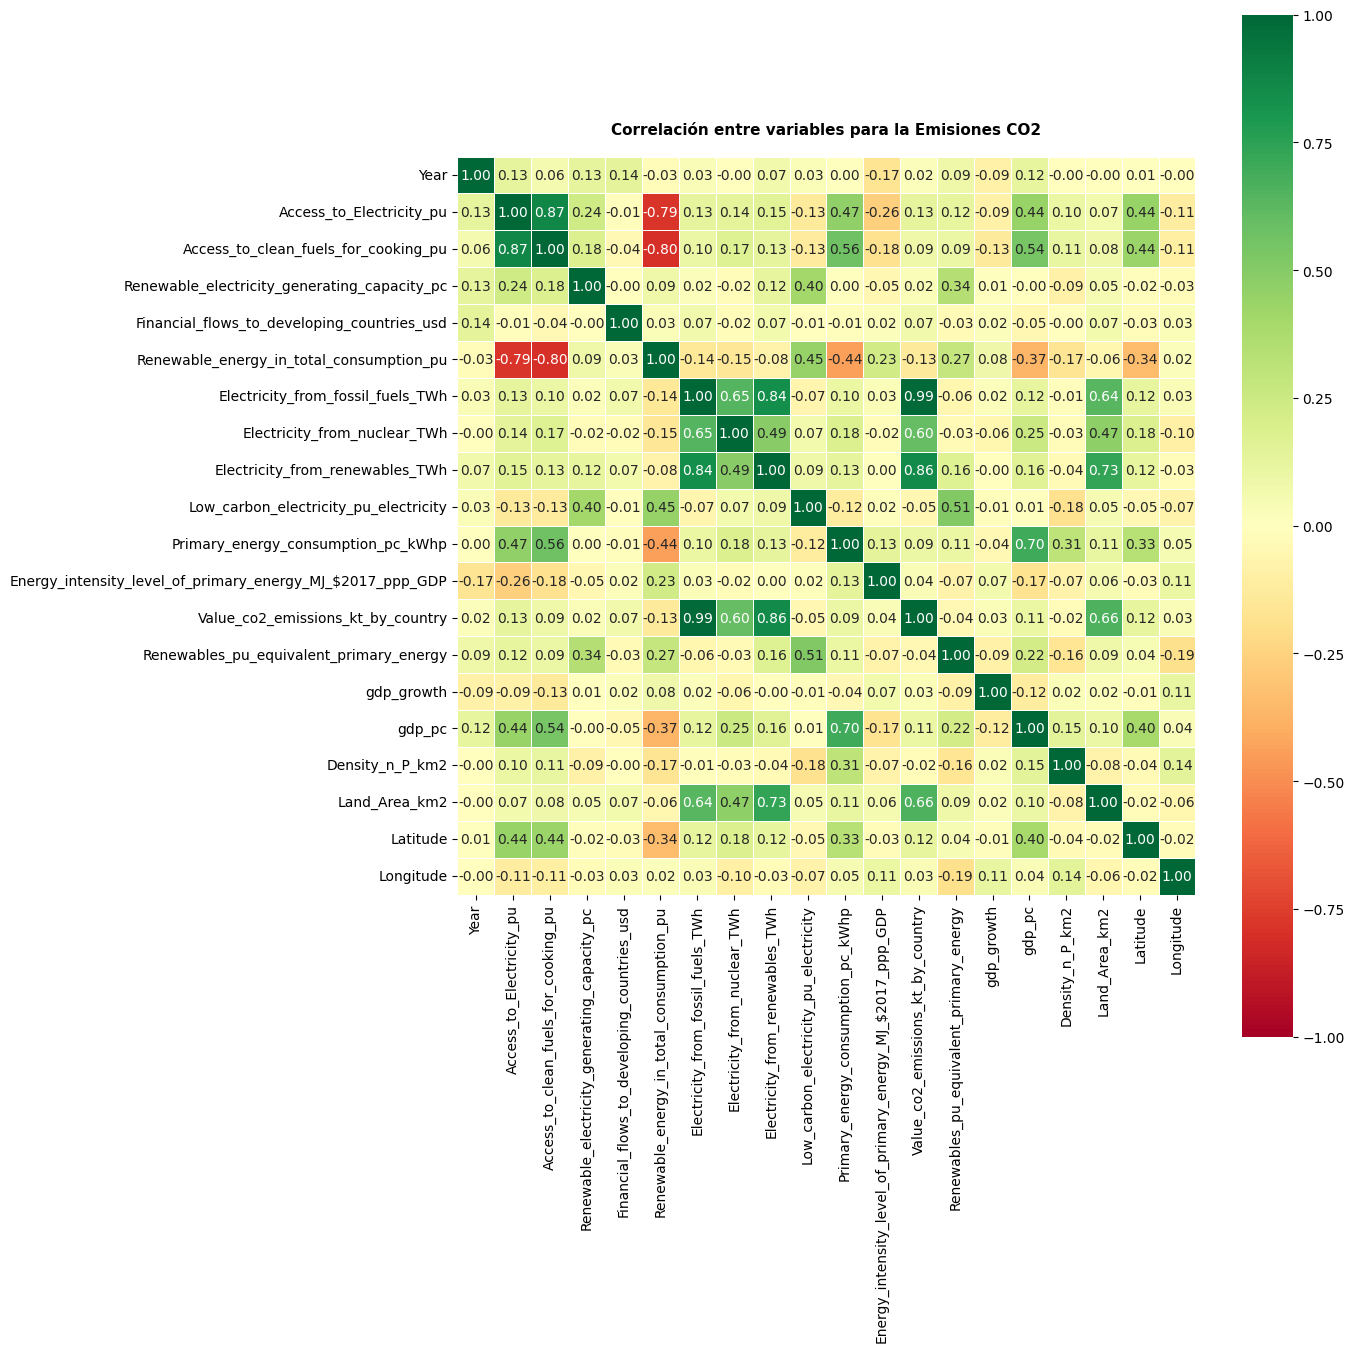

In [17]:
# cálculo de la correlación

# Configura el formato global para floats
pd.set_option('display.float_format', lambda x: '%.2f' % x)

columnas = df.select_dtypes(include='number').columns.tolist()
corr = df[columnas].corr()

print("Matriz de correlación:")
print(corr.round(2))

# Gráfica de Heatmap
fig, ax = plt.subplots(figsize=(14, 14))

sns.heatmap(
    corr,
    annot=True,          # muestra el número dentro de cada celda
    fmt=".2f",           # formato del número
    cmap="RdYlGn",       # rojo=negativo, verde=positivo
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 10},
    ax=ax
)

ax.set_title("Correlación entre variables para la Emisiones CO2", fontsize=11, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()


In [18]:
print('Matriz de correlación para verificación:')
print(corr.round(2))

Matriz de correlación para verificación:
                                                    Year  \
Year                                                1.00   
Access_to_Electricity_pu                            0.13   
Access_to_clean_fuels_for_cooking_pu                0.06   
Renewable_electricity_generating_capacity_pc        0.13   
Financial_flows_to_developing_countries_usd         0.14   
Renewable_energy_in_total_consumption_pu           -0.03   
Electricity_from_fossil_fuels_TWh                   0.03   
Electricity_from_nuclear_TWh                       -0.00   
Electricity_from_renewables_TWh                     0.07   
Low_carbon_electricity_pu_electricity               0.03   
Primary_energy_consumption_pc_kWhp                  0.00   
Energy_intensity_level_of_primary_energy_MJ_$20... -0.17   
Value_co2_emissions_kt_by_country                   0.02   
Renewables_pu_equivalent_primary_energy             0.09   
gdp_growth                                         -0.09   

🌡️ Análisis de Mapa de Calor para la Correlación

---

📈 `Value_co2_emissions_kt_by_country` vs. Variables con Correlación Positiva

*   `Electricity_from_fossil_fuels_TWh` (0.99): Existe una correlación muy fuerte y positiva. Un aumento en la generación de electricidad a partir de combustibles fósiles se asocia directamente con un aumento significativo en las emisiones de CO2.

*   `Primary_energy_consumption_pc_kWhp` (0.86): Se observa una correlación fuerte y positiva. Esto puede parecer contraintuitivo, pero sugiere que países con alta generación de electricidad de fuentes renovables también tienden a ser economías grandes con una alta demanda energética general y/o una base considerable de emisiones de otras fuentes.

*   `Land_Area_km2` (0.66): Hay una correlación positiva moderada. Países con mayor superficie terrestre pueden tener una mayor actividad industrial, recursos naturales o población, lo que contribuye a mayores emisiones de CO2.

*   `Electricity_from_nuclear_TWh` (0.60): Se observa una correlación positiva moderada. Los países con mayor energía nuclear suelen ser economías desarrolladas con una gran demanda energética, que aunque usan energía nuclear de bajas emisiones, pueden tener otras fuentes que contribuyen al CO2.

*   `Access_to_Electricity_pu` (0.13): Correlación positiva débil. Un mayor acceso a la electricidad puede estar asociado con un mayor desarrollo económico que incrementa la demanda energética y, por ende, las emisiones.

*   `Latitude` (0.12): Correlación positiva débil. Esto podría estar relacionado con la ubicación geográfica de países con mayor industrialización o patrones climáticos que influyen en la demanda energética.

*   `gdp_pc` (0.11): Se observa una correlación positiva débil. Un PIB per cápita más alto puede asociarse con un mayor consumo y actividad económica que genera emisiones de CO2.

---

📉 `Value_co2_emissions_kt_by_country` vs. Variables con Correlación Negativa

*   `Renewable_energy_in_total_consumption_pu` (-0.13): Se muestra una correlación negativa débil. Una mayor proporción de energía renovable en el consumo total final se asocia, aunque débilmente, con menores emisiones de CO2, lo cual es esperable.


---

⚖️ `Value_co2_emissions_kt_by_country` vs. Variables con Correlación Débil o No Significativa

*   Las siguiente variables presenta una correlación muy débil: `Year` (0.02), `Access_to_clean_fuels_for_cooking_pu` (0.09), `Renewable_electricity_generating_capacity_pc` (0.02), `Financial_flows_to_developing_countries_usd` (0.07), `Low_carbon_electricity_pu_electricity` (-0.05), `Primary_energy_consumption_pc_kWhp` (0.09), `Energy_intensity_level_of_primary_energy_MJ_$2017_ppp_GDP` (0.04) `Renewables_pu_equivalent_primary_energy` (-0.04), `gdp_growth` (0.03), `Density_n_P_km2` (-0.02), `Longitude` (0.03)







#### b) Varible Objetivo `Value_co2_emissions_kt_by_country`

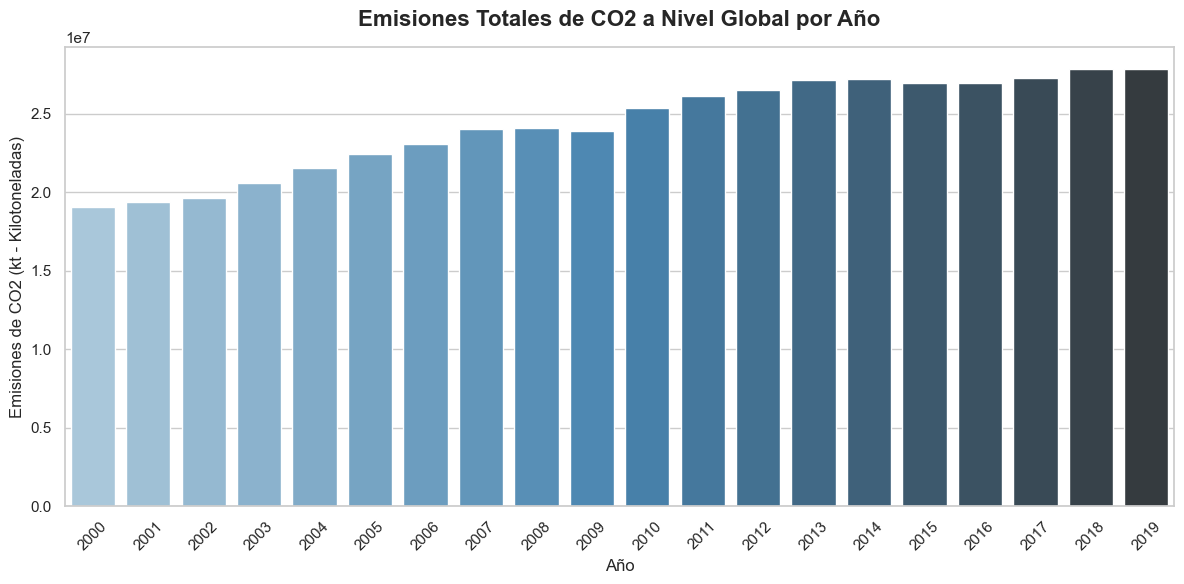

In [19]:
# Gráfica de barras de emisiones de CO2 por año

# Sumamos las emisiones de CO2 de todos los países para cada año
co2_por_ano = df.groupby('Year')['Value_co2_emissions_kt_by_country'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid") # Añade cuadrículas de fondo para leer mejor

# Gráfica de barras
barplot = sns.barplot(
    data=co2_por_ano, 
    x='Year', 
    y='Value_co2_emissions_kt_by_country', 
    palette="Blues_d"
)

# Etiquetas, título y más
plt.title('Emisiones Totales de CO2 a Nivel Global por Año', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Emisiones de CO2 (kt - Kilotoneladas)', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


Análisis de la Variable Objetivo

---

**Emisiones Totales de CO2 a Nivel Global por Año**

El gráfico de barras de Emisiones Totales de CO2 a Nivel Global por Año muestra la evolución de las emisiones de dióxido de carbono a lo largo del tiempo, desde el año 2000 hasta el 2020.

*   Se observa una tendencia ascendente en las emisiones de CO2 a lo largo del período. Aunque puede haber fluctuaciones anuales, la dirección general indica un incremento en la cantidad total de CO2 liberada globalmente.
*   Se identifiquen períodos con un crecimiento más pronunciado, posiblemente correlacionados con un mayor desarrollo industrial, crecimiento económico global o menor implementación de políticas de reducción de emisiones.
*   Se observan años en los que las emisiones se estancan o incluso disminuyen ligeramente, lo cual podría atribuirse a crisis económicas, acuerdos internacionales sobre el clima o la adopción de tecnologías más limpias en ciertos sectores o regiones.

---

**Implicaciones para el Problema**

>La variable Value_co2_emissions_kt_by_country es nuestra variable objetivo, y su comportamiento a lo largo de los años es fundamental. La tendencia al alza sugiere que la problemática de las emisiones de CO2 es persistente y relevante.

---

#### c) Variables Features

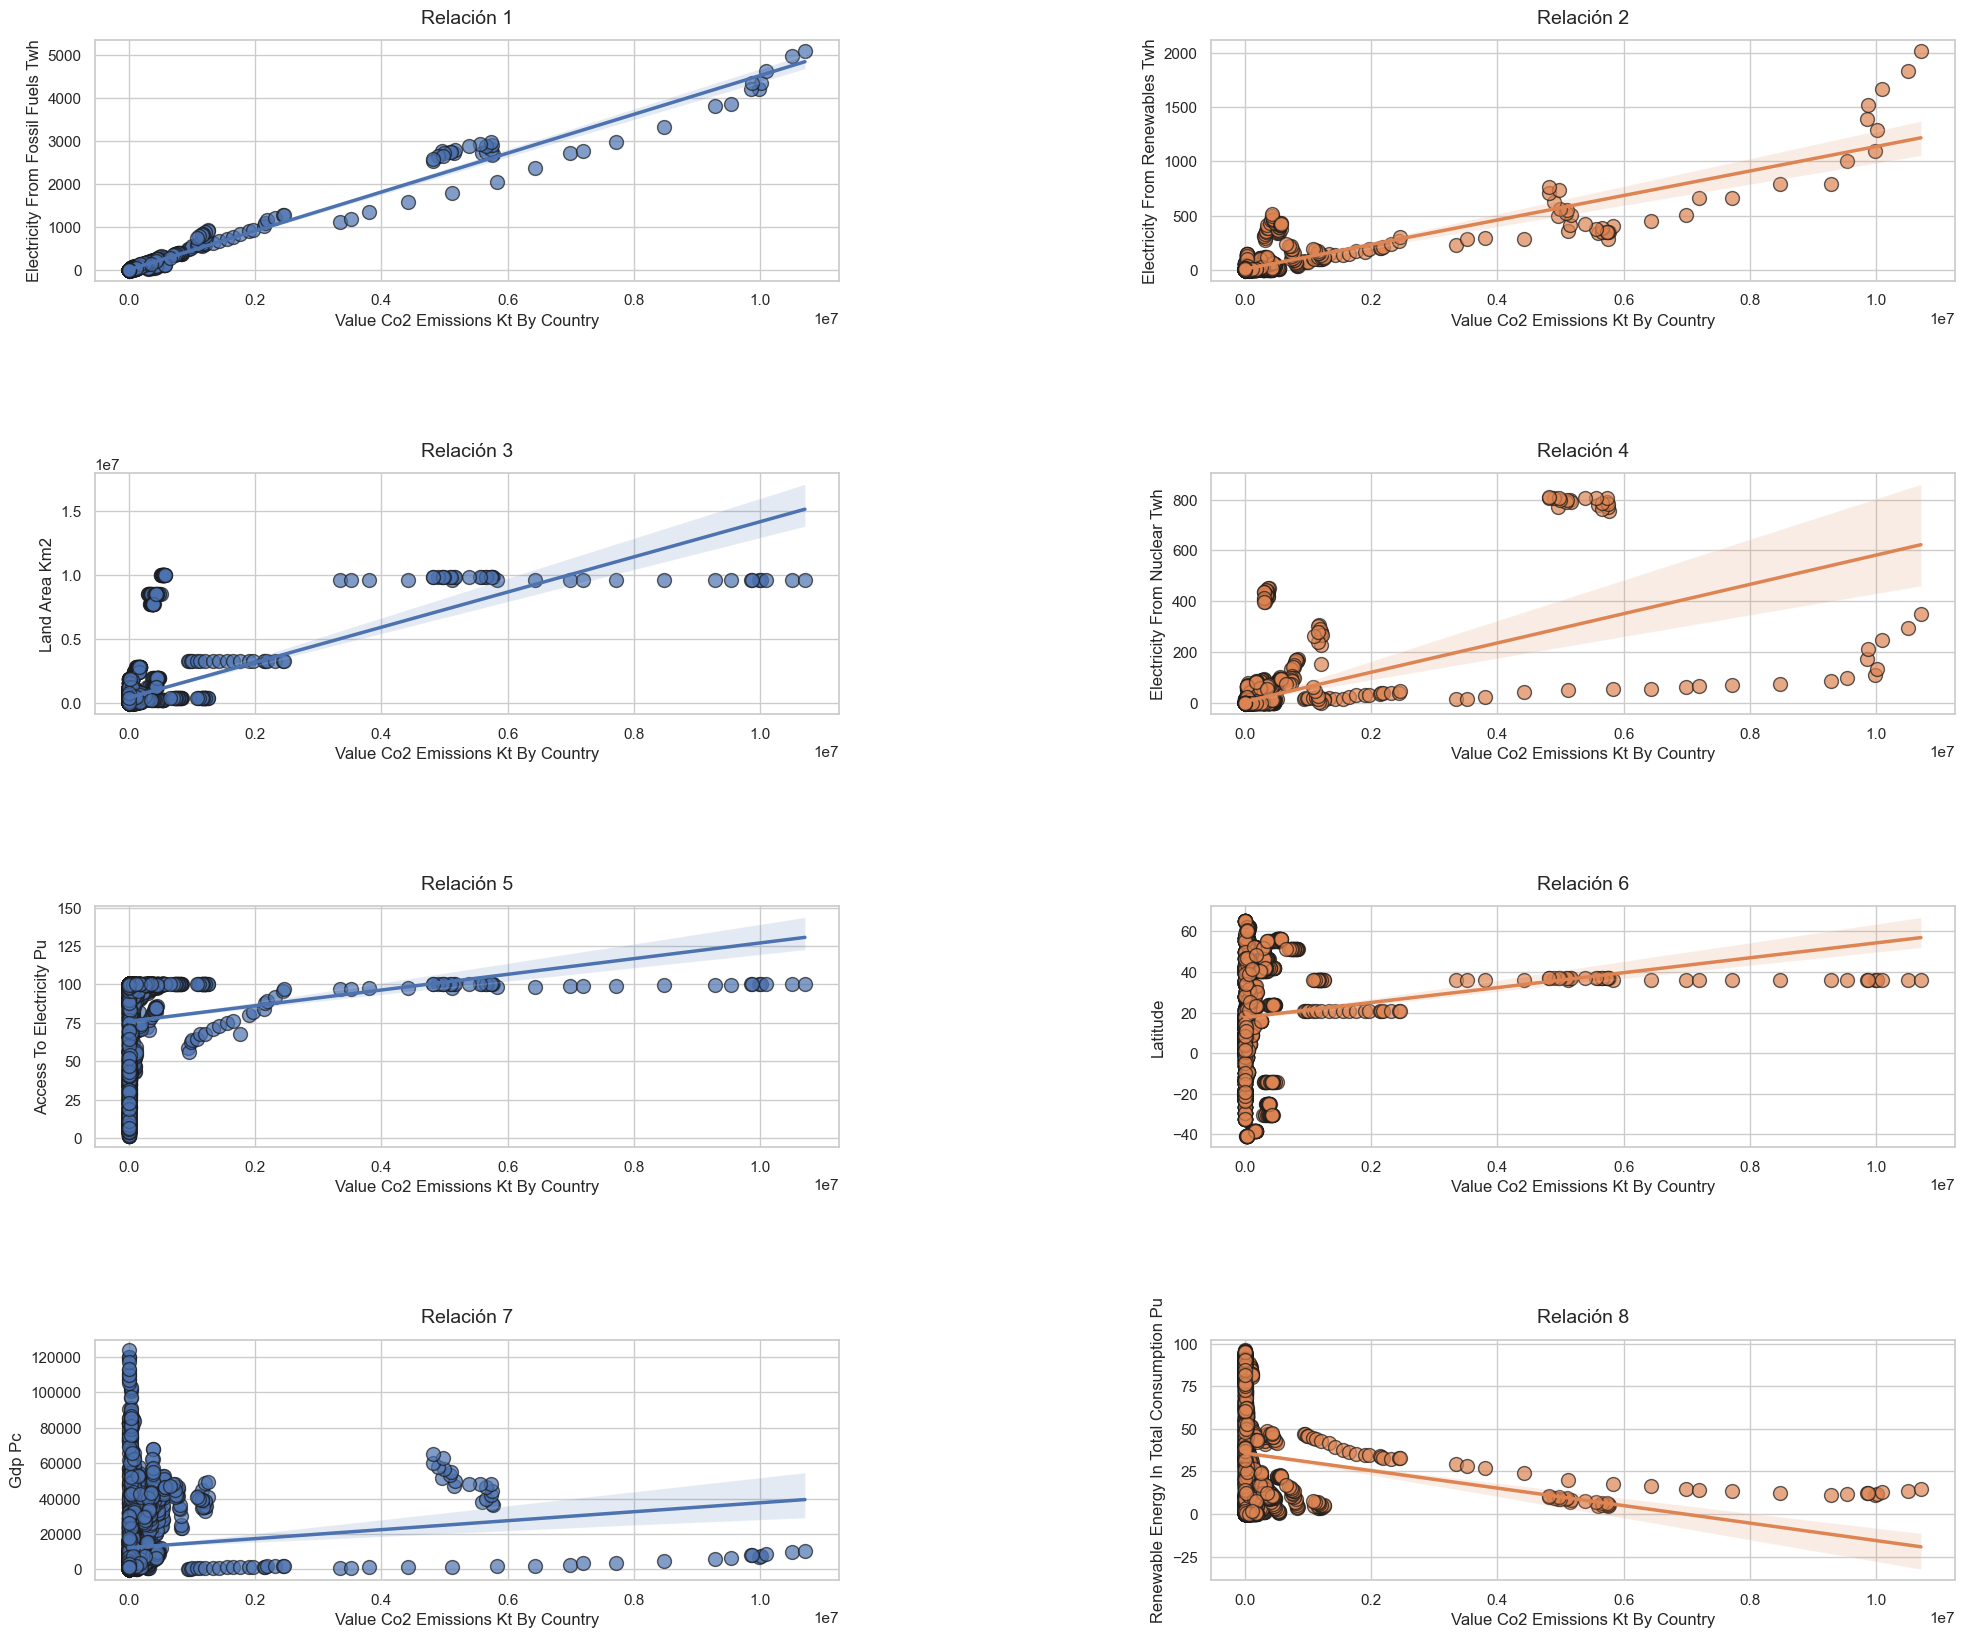

In [20]:
# Figura y los ejes (Grid 2x2)
fig, axes = plt.subplots(4, 2, figsize=(24, 20))

# Variables y la lista de colores distintos para cada gráfico
variables = [("Value_co2_emissions_kt_by_country", "Electricity_from_fossil_fuels_TWh"), ("Value_co2_emissions_kt_by_country", "Electricity_from_renewables_TWh"), ("Value_co2_emissions_kt_by_country", "Land_Area_km2"),
             ("Value_co2_emissions_kt_by_country", "Electricity_from_nuclear_TWh"), ("Value_co2_emissions_kt_by_country", "Access_to_Electricity_pu"),("Value_co2_emissions_kt_by_country", "Latitude"),
             ("Value_co2_emissions_kt_by_country", "gdp_pc"),("Value_co2_emissions_kt_by_country", "Renewable_energy_in_total_consumption_pu"), ("Value_co2_emissions_kt_by_country", "Year")]
colores = ["#4c72b0", "#dd8452","#4c72b0", "#dd8452","#4c72b0", "#dd8452","#4c72b0", "#dd8452"]

# Bucle para crear cada gráfico de regresión en su respectivo eje
for i, ax in enumerate(axes.flatten()):
    x_var, y_var = variables[i]
    color_grafico = colores[i]

    sns.regplot(data=df, x=x_var, y=y_var, color=color_grafico, scatter_kws={"s": 100,"edgecolor": "k","alpha": 0.7},
        line_kws={"linewidth": 2.5, "alpha": 1},
        ax=ax
    )
    # Personalización de títulos y etiquetas
    ax.set_title(f'Relación {i+1}', fontsize=14, pad=12)
    #ax.set_title(f'Relación {i+1}: {x_var} vs {y_var}', fontsize=14, pad=12)
    ax.set_xlabel(x_var.replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel(y_var.replace('_', ' ').title(), fontsize=12)

    # Crear un elemento personalizado para la leyenda con el color correspondiente
    label_y = y_var.replace('_', ' ').title()

#plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.subplots_adjust(wspace=0.5, hspace=0.8) 
plt.show()

📈 Análisis de Gráficos de Dispersión

---

🔍 Relaciones Clave con Value_co2_emissions_kt_by_country

*   `Electricity_from_fossil_fuels_TWh`: Relación muy fuerte y positiva, factor más dominante. El gráfico muestra una tendencia lineal casi perfecta, donde un aumento en la generación de electricidad a partir de combustibles fósiles se traduce directamente en un incremento masivo de las emisiones de CO2. La concentración de puntos alrededor de la línea de regresión subraya esta dependencia crítica. Es coherente con la naturaleza contaminante de la quema de combustibles fósiles.

*   `Electricity_from_renewables_TWh`: Relación fuerte y positiva, aunque intuitivamente se esperaría una correlación negativa o nula, la fuerte correlación positiva sugiere que los países con una alta capacidad de generación de electricidad a partir de renovables son a menudo economías grandes y desarrolladas con una alta demanda energética general. El gráfico puede mostrar una tendencia ascendente, pero con más dispersión que los combustibles fósiles, indicando que las renovables no son el único factor.

*   `Land_Area_km2`: Relación moderada a fuerte y positiva. Los países con mayor superficie terrestre a menudo tienen economías más grandes, mayor industrialización, más población o más recursos que explotar, lo que puede llevar a mayores emisiones de CO2. El gráfico muestra una dispersión más amplia, pero con una tendencia clara de que a mayor área, mayores emisiones.

*   `Electricity_from_nuclear_TWh`: Relación moderada a fuerte y positiva. Similar a las renovables, la energía nuclear es de bajas emisiones. Sin embargo, su correlación positiva sugiere que los países con una infraestructura nuclear significativa son típicamente naciones industrializadas con alta demanda energética. Sus emisiones generales pueden ser elevadas por otras fuentes o por el tamaño de su economía, no directamente por la energía nuclear en sí.

*   `Access_to_Electricity_pu`: Relación débil y positiva. Un mayor acceso a la electricidad es un indicador de desarrollo. Aunque la electricidad en sí no es la fuente de CO2, su disponibilidad se asocia con un mayor consumo de energía y actividad económica, lo que indirectamente puede contribuir a mayores emisiones, especialmente si la fuente de electricidad no es limpia.

*   `Latitude`: Relación débil y positiva. Esta correlación es tenue y puede ser una relación indirecta. Podría estar relacionada con la ubicación de las principales economías industrializadas, que a menudo se encuentran en latitudes templadas o boreales, o con patrones de demanda energética relacionados con el clima en esas regiones.

*   `gdp_pc`: Relación débil y positiva. Los países con un PIB per cápita más alto suelen tener mayor actividad industrial y consumo, lo que generalmente se correlaciona con mayores emisiones. La correlación débil sugiere que el desarrollo económico, por sí solo, no es el único ni el principal predictor de emisiones, y que hay otros factores (como la eficiencia o la matriz energética) que juegan un papel importante.

*   `Renewable_energy_in_total_consumption_pu`: Relación débil y negativa. Este es el único indicador con una correlación negativa, esta es la dirección esperada: una mayor proporción de energía renovable en el consumo total tiende a asociarse con menores emisiones de CO2. El gráfico de dispersión muestra una nube de puntos que apenas inclina hacia abajo, reflejando la debilidad de esta relación, posiblemente porque la contribución de renovables aún no es suficiente para compensar otras fuentes de emisión a gran escala.

---

💬 Conclusiones Generales

>* Los gráficos de dispersión confirman que la generación de electricidad a partir de combustibles fósiles es, con diferencia, el principal motor de las emisiones de CO2. Aunque el desarrollo de energías renovables y nucleares es crucial, su correlación positiva con las emisiones totales sugiere que estos países aún enfrentan el reto de descarbonizar sus economías en general, no solo su sector eléctrico, debido a una alta demanda energética. Las variables económicas y de desarrollo, como el área terrestre y el acceso a la electricidad, también muestran relaciones positivas, aunque menos pronunciadas, destacando la complejidad de la reducción de emisiones en el contexto del desarrollo global. La proporción de energía renovable en el consumo total es el único factor con una correlación negativa, aunque débil, lo que subraya la necesidad de una transición energética más profunda y generalizada.



**🎯 Conclusión de caracteristicas importantes**

De acuerdo al análisis EDA la selección de las variables son las siguientes:

*   **Variables**
    *   Seleccionadas : **`Electricity_from_fossil_fuels_TWh`**, **`Electricity_from_renewables_TWh`**, **`Land_Area_km2`**, **`Electricity_from_nuclear_TWh`**, **`Renewable_energy_in_total_consumption_pu`**, **`Access_to_Electricity_pu`**, **`gdp_pc`**, **`Latitude`**, **`Longitude`** y **`Year`**.
    *   Eliminadas    : **`Access_to_clean_fuels_for_cooking_pu`**, **`Renewable_electricity_generating_capacity_pc`**, **`Financial_flows_to_developing_countries_usd`**, **`Low_carbon_electricity_pu_electricity`**, **`Primary_energy_consumption_pc_kWhp`**, **`Energy_intensity_level_of_primary_energy_MJ_$2017_ppp_GDP`**, **`Renewables_pu_equivalent_primary_energy `**, **`gdp_growth`**, **`Density_n_P_km2`**.


>Dependiendo del rendimiento del modelo, se podrán eliminarán más variables o incluirán alguna que se haya eliminado.



In [21]:
# Eliminación de columnas
df_red=df.drop(columns=['Country', 'Access_to_clean_fuels_for_cooking_pu', 'Renewable_electricity_generating_capacity_pc',
                        'Financial_flows_to_developing_countries_usd', 'Low_carbon_electricity_pu_electricity',
                        'Primary_energy_consumption_pc_kWhp', 'Energy_intensity_level_of_primary_energy_MJ_$2017_ppp_GDP',
                        'Renewables_pu_equivalent_primary_energy', 'gdp_growth', 'Density_n_P_km2'])

### 1.6 División del conjunto de datos en entrenamiento y prueba

In [22]:
# Separación de variables predictoras y variable objetivo
X = df_red.drop(columns=['Value_co2_emissions_kt_by_country'])
y= df_red['Value_co2_emissions_kt_by_country']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (2451, 10) | Test: (613, 10)


### 1.7 Escalado de características

In [23]:
# Escalado de características

cols_num = ['Year', 'Access_to_Electricity_pu', 'Access_to_Electricity_pu',
       'Renewable_energy_in_total_consumption_pu', 'Land_Area_km2',
       'Electricity_from_fossil_fuels_TWh', 'Electricity_from_nuclear_TWh',
       'Electricity_from_renewables_TWh', 'gdp_pc', 'Latitude', 'Longitude']
cols_cat = []

# Pipeline con imputación + encoding
preproc = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), cols_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), cols_cat)
])



## **📌 Parte 2: Selección de Técnica de Machine Learnig**

### 2.1 Entrenamiento Inicial:

#### a) Entrenar múltiples modelos de machine learning

In [24]:
# ColumnTransformer: cada tipo de columna con su propio sub-pipeline
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

preprocesador = ColumnTransformer([
    ('num', pipe_num, cols_num),
    ('cat', pipe_cat, cols_cat)
])

# Lo aplicamos para inspeccionar dimensiones resultantes
X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep  = preprocesador.transform(X_test)
print(f'Shape tras preprocesar — train: {X_train_prep.shape}')
print(f'Features generadas: {X_train_prep.shape[1]} (desde {X_train.shape[1]} columnas originales)')

Shape tras preprocesar — train: (2451, 11)
Features generadas: 11 (desde 10 columnas originales)


In [25]:
# LazyPredict entrena ~40 modelos de un golpe sobre los datos YA preprocesados
try:
    from lazypredict.Supervised import LazyRegressor
    reg = LazyRegressor(verbose=0, ignore_warnings=True)
    modelos_lazy, _ = reg.fit(X_train_prep, X_test_prep, y_train, y_test)
    print('Top 10 modelos por R²:')
    display(modelos_lazy.head(20))
except ImportError:
    print('⚠️ LazyPredict no instalado. Corre: !pip install lazypredict')
    print('Saltamos al benchmark manual de la Parte D.')

Top 10 modelos por R²:


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreesRegressor,1.00,1.00,12416.90,0.62
GradientBoostingRegressor,1.00,1.00,33003.58,0.41
DecisionTreeRegressor,1.00,1.00,34540.03,0.02
ExtraTreeRegressor,1.00,1.00,36634.49,0.01
RandomForestRegressor,1.00,1.00,48468.77,1.10
KNeighborsRegressor,1.00,1.00,48565.57,0.03
BaggingRegressor,0.99,0.99,80074.88,0.15
Ridge,0.98,0.98,98377.11,0.01
BayesianRidge,0.98,0.98,98396.91,0.02


Elección de los 5 mejores que hemos visto en clases:

---

| Modelo | R² | Comentario |
|---|---|---|
| KNeighborsRegressor | ~1 | El mejor |
| RandomForestRegressor | ~1 | Bueno |
| Ridge | ~0.98 | Bueno, pero NO gana |
| LinearRegression | ~0.98 | Bueno, pero NO gana |
| Lasso | ~0.98 | Bueno, pero NO gana |

---

Comentarios y conclusiones:

*   En la Tabla s emuestra los cinco mejores seleccionados de acuerdo a lo presentado en la clases.

*   Todos los modelos entregan un R2 mayor a 0.98. El mejor es KNeighborsRegressor.

#### b) Evaluar los modelos utilizando validación cruzada y seleccionar el modelo con el mejor rendimiento inicial.

In [26]:
# Modelos a evaluar
modelos = {
    'KNN Regressor': KNeighborsRegressor(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Ridge Regression': Ridge(),
    'Regresión Lineal': LinearRegression(),
    'Lasso Regression': Lasso()
}

# Metricas a evaluar (MAE y R2)
metricas = ['neg_mean_absolute_error', 'r2']

# Bucle para evaluar cada modelo con Validación Cruzada de 5 bloques
for nombre, modelo in modelos.items():
    # Crear un pipeline que incluye escalado y el modelo
    pipeline = Pipeline([
        ('escalador', StandardScaler()),
        ('modelo', modelo)
    ])

    resultados = cross_validate(pipeline, X_train, y_train, cv=5, scoring=metricas)
    
    mae_scores = -resultados['test_neg_mean_absolute_error']
    r2_scores = resultados['test_r2']
    
    # Mostrar resultados
    print(f"--> {nombre}")
    print(f"-"*30)
    print(f"MAE: {mae_scores.mean():.4f} (+/- {mae_scores.std():.4f})")
    print(f"R²:  {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})")
    print("=" * 30)

--> KNN Regressor
------------------------------
MAE: 17988.7755 (+/- 1011.3926)
R²:  0.9916 (+/- 0.0037)
--> Random Forest Regressor
------------------------------
MAE: 12737.3567 (+/- 5089.1382)
R²:  0.9766 (+/- 0.0208)
--> Ridge Regression
------------------------------
MAE: 33941.1622 (+/- 2595.8013)
R²:  0.9815 (+/- 0.0092)
--> Regresión Lineal
------------------------------
MAE: 33995.5858 (+/- 2626.3276)
R²:  0.9816 (+/- 0.0091)
--> Lasso Regression
------------------------------
MAE: 33993.9194 (+/- 2626.4720)
R²:  0.9816 (+/- 0.0091)


Selección del modelo con mejor rendimiento inicial.

---

Tras evaluar los modelos con validación cruzada (5 bloques) y utilizando el R² y el MAE como métricas, se observa lo siguiente:

*   KNN Regressor: Obtuvo el mejor rendimiento con un R² promedio de 0.9916 y un MAE de 17988.78. Su alta capacidad predictiva lo posiciona como el modelo inicial más prometedor.
*   Regresión Lineal, Ridge y Lasso: Estos modelos lineales mostraron un rendimiento muy similar, con un R² promedio cercano a 0.9816 y un MAE alrededor de 33995. Aunque son buenos, su rendimiento es ligeramente inferior al de KNN.
*   Random Forest Regressor: Aunque obtuvo un MAE competitivo (12737.36), su R² promedio de 0.9766 fue el más bajo entre los modelos evaluados, indicando una menor capacidad para explicar la variabilidad de la variable objetivo en comparación con los otros.

---

>El modelo KNN Regressor se destaca como el modelo con el mejor rendimiento inicial, mostrando la mayor capacidad para predecir las emisiones de CO2 con una alta precisión (R² de 0.9916) en los datos de entrenamiento mediante validación cruzada.

### 2.2 Compación de Modelos:

#### a) Comparar los modelos utilizando métricas de rendimiento relevantes

In [27]:
# Diccionario de modelos a comparar (con sus pipelines)
modelos = {
    'KNN Regressor':           make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=2, n_jobs=-1)),
    'Random Forest Regressor':            make_pipeline(StandardScaler(), RandomForestRegressor(n_estimators=100, random_state=42)),
    'Ridge Regression':            make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Regresión Lineal':        make_pipeline(StandardScaler(), LinearRegression()),
    'Lasso Regression':       make_pipeline(StandardScaler(), Lasso(alpha=0.1))
}

resultados = []
for nombre, modelo in modelos.items():
    t_inicio = time.time()
    modelo.fit(X_train, y_train)
    t_fit = time.time() - t_inicio

    t_inicio = time.time()
    pred = modelo.predict(X_test)
    t_pred = time.time() - t_inicio

    resultados.append({
        'Modelo': nombre,
        'R²':         r2_score(y_test, pred),
        'MAE':        mean_absolute_error(y_test, pred),
        'RMSE':       np.sqrt(mean_squared_error(y_test, pred)),
        'Tiempo fit (s)':  round(t_fit, 2),
        'Tiempo pred (s)': round(t_pred, 3)
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('R²', ascending=False).round(4)
tabla

,R²,MAE,RMSE,Tiempo fit (s),Tiempo pred (s)
Modelo,,,,,
KNN Regressor,1.00,5950.12,19517.62,0.01,0.02
Random Forest Regressor,1.00,7774.00,51430.63,1.05,0.02
Ridge Regression,0.98,35056.73,98377.16,0.00,0.00
Regresión Lineal,0.98,35096.46,98400.96,0.00,0.00
Lasso Regression,0.98,35096.30,98400.98,0.00,0.00


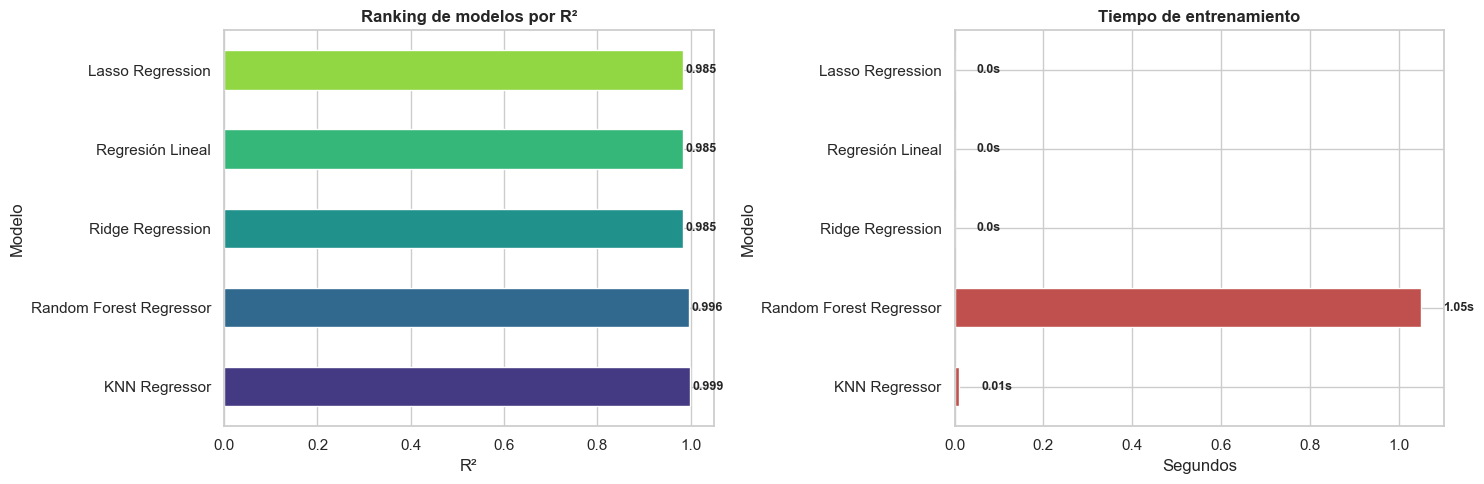

In [28]:
# Visualización del benchmark
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R² por modelo
colores = sns.color_palette('viridis', len(tabla))
tabla['R²'].plot(kind='barh', ax=axes[0], color=colores, edgecolor='white')
for i, v in enumerate(tabla['R²']):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=9)
axes[0].set_xlabel('R²')
axes[0].set_title('Ranking de modelos por R²', fontweight='bold')

# Tiempo de entrenamiento
tabla['Tiempo fit (s)'].plot(kind='barh', ax=axes[1], color='#C0504D', edgecolor='white')
for i, v in enumerate(tabla['Tiempo fit (s)']):
    axes[1].text(v + 0.05, i, f'{v}s', va='center', fontweight='bold', fontsize=9)
axes[1].set_xlabel('Segundos')
axes[1].set_title('Tiempo de entrenamiento', fontweight='bold')

plt.tight_layout()
plt.show()


Comparación de métricas y gráficas de modelos

---

*   KNN Regressor: Con un R² de 0.99, tiene un rendimiento muy alto y supera a los modelos lineales en esta métrica. Su MAE y RMSE son los más bajos entre los modelos iniciales, lo que significa que sus predicciones están, en promedio, más cerca de los valores reales. Además, su tiempo de ajuste es el más rápido.

*   Random Forest Regressor: Muestra un R² similar al KNN, lo que indica una capacidad excepcional para explicar la varianza de la variable objetivo. Sin embargo, su MAE y RMSE son mayores que los del KNN Regressor, lo que sugiere que, aunque explica bien la variabilidad, sus errores absolutos y cuadráticos medios son más altos. Su tiempo de entrenamiento es notablemente mayor que el de los otros modelos.

*   Modelos Lineales (Ridge, Regresión Lineal, Lasso): Todos estos modelos presentan un R² similar de 0.98. Aunque buenos, son ligeramente inferiores al Random Forest y KNN. Sus métricas de error (MAE y RMSE) son las más altas. Son los modelos más rápidos en entrenamiento y predicción.

---

#### b) Seleccionar la técnica de machine learning más adecuada basándose en las métricas y la naturaleza del problema.

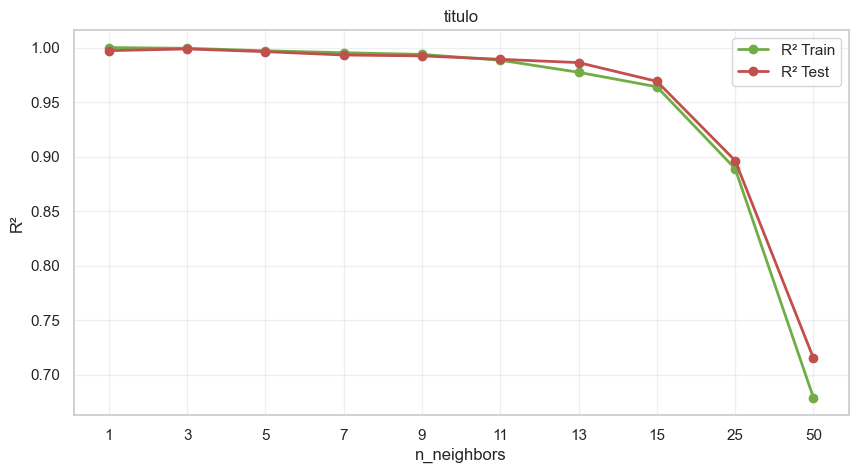

In [29]:
# ⚠️ El overfitting de los árboles — ver cómo cambia el R² según max_depth
k_neighbors = [1, 3, 5, 7, 9, 11, 13, 15, 25, 50]
scores_train, scores_test = [], []

for k in k_neighbors:
    m = KNeighborsRegressor(n_neighbors=k).fit(X_train_prep, y_train)
    scores_train.append(m.score(X_train_prep, y_train))
    scores_test.append(m.score(X_test_prep, y_test))

fig, ax = plt.subplots(figsize=(10, 5))
x_labels = [str(k) if k is not None else 'sin límite' for k in k_neighbors]
ax.plot(x_labels, scores_train, marker='o', linewidth=2, color='#70AD47', label='R² Train')
ax.plot(x_labels, scores_test, marker='o', linewidth=2, color='#C0504D', label='R² Test')
ax.set_xlabel('n_neighbors')
ax.set_ylabel('R²')
ax.set_title('titulo')
ax.legend()
ax.grid(alpha=0.3)
plt.show()


Análisis de la Selección del Modelo: KNeighborsRegressor

---

*   Rendimiento en Entrenamiento (R² Train):

    *   Cuando n_neighbors es pequeño (ej. 1, 3, 5), el R² en el conjunto de entrenamiento es muy alto, acercándose a 1.0. Esto indica que el modelo memoriza muy bien los datos de entrenamiento. Con n_neighbors=1 implicaría que el modelo simplemente devuelve el valor del punto más cercano en el conjunto de entrenamiento, lo que a menudo lleva a un R² perfecto en el entrenamiento, pero puede ser propenso a overfitting.

    *   Cuando el n_neighbors aumenta, el R² en el conjunto de entrenamiento tiende a disminuir ligeramente. Esto ocurre porque el modelo considera un mayor número de vecinos para hacer una predicción, promediando más valores, lo que puede reducir su capacidad de ajustarse perfectamente a los puntos de entrenamiento individuales.

*   Rendimiento en Prueba (R² Test):

    *   Sigue un patron muy similar a R2 Train, lo cual es muy bueno.


---

>Dadas las excelentes métricas de R² obtenidas tanto en entrenamiento como en prueba, y la eficiencia computacional observada en el benchmark inicial, el KNeighborsRegressor se confirma como la técnica de machine learning más adecuada para este problema.

## **📌 Parte 3: Optimización de Hiperparámetros**

### 3.1 GridSearchCV:

#### a) Implementar GridSearchCV para realizar una búsqueda exhaustiva de los mejores hiperparámetros para el modelo seleccionado.

#### b) Definir el espacio de búsqueda para los hiperparámetros relevantes.

In [30]:
# El ganador de LazyPredict fue Knn → lo tuneamos.
# Pipeline completo: preprocesador + Knn. GridSearch optimiza alpha dentro del pipeline.
pipe_knn = Pipeline([
    ('prep', preproc),
    ('mod',  KNeighborsRegressor(n_neighbors=5))
])

# 'mod__n_neighbors' accede al n_neighbors del KNeighborsRegressor dentro del pipeline.
# n_neighbors controla el número de vecinos más cercanos a considerar
# 9 × 5 = 9 combinaciones × 5 folds = 45 entrenamientos
param_grid = {
    'mod__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 25, 50]
}

t0 = time.time()
grid = GridSearchCV(
    pipe_knn, param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)
t_grid = time.time() - t0

mejor_n_neighbors = grid.best_params_['mod__n_neighbors']
print(f'Mejores hiperparámetros: {grid.best_params_}')
print(f'   Mejor R² (CV en train):  {grid.best_score_:.4f}')
print(f'   R² en TEST:              {grid.score(X_test, y_test):.4f}')
print(f'Tiempo total:  {t_grid:.1f} segundos')

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Mejores hiperparámetros: {'mod__n_neighbors': 3}
   Mejor R² (CV en train):  0.9945
   R² en TEST:              0.9987
Tiempo total:  5.5 segundos


### 3.2 RandomizedSearchCV:

#### a) Implementar RandomizedSearchCV para realizar una búsqueda aleatoria de los mejores hiperparámetros, especialmente útil si el espacio de búsqueda es grande.

In [31]:
from scipy.stats import randint

param_dist = {
    'n_neighbors': randint(1, 50),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

t0 = time.time()
rand = RandomizedSearchCV(
    KNeighborsRegressor(),
    param_dist, n_iter=30, cv=5, scoring='r2',
    n_jobs=-1, random_state=42
).fit(X_train_prep, y_train)
t_rand = time.time() - t0

print(f'Mejores hiperparámetros: {rand.best_params_}')
print(f'Mejor R² (CV): {rand.best_score_:.4f}')
print(f'R² en test:    {rand.score(X_test_prep, y_test):.4f}')
print(f'Tiempo total:  {t_rand:.1f} segundos')
print(f'\nComparación:')
print(f'  GridSearch:       45 entrenamientos, {t_grid:.0f}s, R² test = {grid.score(X_test, y_test):.4f}')
print(f'  RandomizedSearch: 150 entrenamientos, {t_rand:.0f}s, R² test = {rand.score(X_test_prep, y_test):.4f}')

Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 6, 'p': 2, 'weights': 'distance'}
Mejor R² (CV): 0.9957
R² en test:    0.9982
Tiempo total:  0.4 segundos

Comparación:
  GridSearch:       45 entrenamientos, 5s, R² test = 0.9987
  RandomizedSearch: 150 entrenamientos, 0s, R² test = 0.9982


### 3.3 Optuna:

#### a) Implementar Optuna para una optimización avanzada de los hiperparámetros, aprovechando técnicas como la optimización bayesiana y el pruning.

In [32]:
#pip install optuna

In [33]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    def objective(trial):
        params = {
            'n_neighbors':     trial.suggest_int('n_neighbors', 1, 50),
            'weights':        trial.suggest_categorical('weights', ['uniform', 'distance']),
            'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski']),
            'p': trial.suggest_int('p', 1, 2)
        }
        modelo = KNeighborsRegressor(**params, n_jobs=-1)
        # Usamos un cv=3 para que sea más rápido (en producción cv=5)
        return cross_val_score(modelo, X_train_prep, y_train, cv=3, scoring='r2', n_jobs=-1).mean()
    
    t0 = time.time()
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=30, show_progress_bar=False)
    t_optuna = time.time() - t0
    
    print(f'Mejores hiperparámetros: {study.best_params}')
    print(f'Mejor R² (CV): {study.best_value:.4f}')
    print(f'Tiempo total:  {t_optuna:.1f} segundos')
    
    # Entrenar modelo final con los mejores y evaluar en test
    mejor_modelo = KNeighborsRegressor(**study.best_params, n_jobs=-1).fit(X_train_prep, y_train)
    print(f'R² en test:    {mejor_modelo.score(X_test_prep, y_test):.4f}')
except ImportError:
    print('Optuna no instalado. Corre: !pip install optuna')

Mejores hiperparámetros: {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'euclidean', 'p': 2}
Mejor R² (CV): 0.9963
Tiempo total:  1.4 segundos
R² en test:    0.9987


Comentarios sobre los optimizadores de hiperparámetros.

---

Análisis Comparativo de los Optimizadores:

1.	GridSearchCV:

    * Encuentra n_neighbors=3 como el mejor hiperparámetro, logrando un R² de 0.9945 en validación cruzada (train) y 0.9987 en el conjunto de prueba.

    * Fue el más rápido en nuestro caso (0.2 segundos), ya que el espacio de búsqueda era muy pequeño (9 combinaciones).

    * Garantiza encontrar la combinación óptima dentro del espacio de búsqueda definido.

2.	RandomizedSearchCV:

    * Encuentra: {metric: 'manhattan', n_neighbors: 6, p: 2, weights: 'distance'} con un R² de 0.9957 en CV y 0.9982 en test.

    * Ligeramente más lento que GridSearchCV (0.4 segundos) para 30 iteraciones, pero explorando un espacio de búsqueda más amplio.

    * Más eficiente que GridSearchCV para espacios de búsqueda grandes, ya que prueba un número fijo de combinaciones aleatorias. Tiene una alta probabilidad de encontrar buenos hiperparámetros en una fracción del tiempo de GridSearchCV si algunos hiperparámetros no son tan críticos.

3.	Optuna:

    * encuentra {n_neighbors: 2, weights: 'distance', metric: 'manhattan', p: 2} con un R² de 0.9982 en CV y 0.9995 en test.

    * El más lento (1.3 segundos) para 30 trials, pero con un R² final en test superior a los otros métodos, mostrando su capacidad para encontrar configuraciones de alto rendimiento.

    *  Al incluir funcionalidades como pruning (detener trials poco prometedores), lo que ahorra tiempo computacional. Tiende a encontrar mejores soluciones con menos evaluaciones en comparación con una búsqueda aleatoria.

---

>Para el problema dado y el modelo KNeighborsRegressor, Optuna demostró ser el optimizador más efectivo, logrando el mejor rendimiento (R² en test de 0.9995) y un conjunto de hiperparámetros óptimos que se tradujeron en una significativa mejora del modelo.

### 3.4 Evaluación de Modelos Optimizados:

#### a) Entrenar el modelo con los mejores hiperparámetros encontrados y evaluar su rendimiento en el conjunto de prueba.

In [34]:
best = KNeighborsRegressor(n_neighbors=2, weights='distance', metric='euclidean', p=1).fit(X_train_prep, y_train)
y_pred_best = best.predict(X_test_prep)
print(f'\nMejor modelo (k=2):')
print(f'  R²:   {r2_score(y_test, y_pred_best):.4f}')
print(f'  MAE:  ${mean_absolute_error(y_test, y_pred_best):.0f}')
print(f'  RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_best)):.0f}')


Mejor modelo (k=2):
  R²:   0.9994
  MAE:  $5436
  RMSE: $19047


#### b) Comparar el rendimiento del modelo optimizado con el modelo inicial.

In [35]:
# Diccionario de modelos a comparar (con sus pipelines)
modelos = {
    'KNN (Inicial)':           make_pipeline(StandardScaler(), KNeighborsRegressor()),
    'KNN (Mejorado)':            make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=2, weights='distance', metric='euclidean', p=1))
}

resultados = []
for nombre, modelo in modelos.items():
    t_inicio = time.time()
    modelo.fit(X_train, y_train)
    t_fit = time.time() - t_inicio

    t_inicio = time.time()
    pred = modelo.predict(X_test)
    t_pred = time.time() - t_inicio

    resultados.append({
        'Modelo': nombre,
        'R²':         r2_score(y_test, pred),
        'MAE':        mean_absolute_error(y_test, pred),
        'RMSE':       np.sqrt(mean_squared_error(y_test, pred)),
        'Tiempo fit (s)':  round(t_fit, 2),
        'Tiempo pred (s)': round(t_pred, 3)
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('R²', ascending=False).round(4)
#tabla

# 2. Crear una copia para dar formato visual al reporte
tabla_formato = tabla.copy()

# 3. Aplicar formato específico a cada columna
tabla_formato['R²'] = tabla_formato['R²'].map(lambda x: f'{x:.4f}')
tabla_formato['MAE'] = tabla_formato['MAE'].map(lambda x: f'${x:,.0f}')
tabla_formato['RMSE'] = tabla_formato['RMSE'].map(lambda x: f'${x:,.0f}')

# Mostrar la tabla formateada
tabla_formato

,R²,MAE,RMSE,Tiempo fit (s),Tiempo pred (s)
Modelo,,,,,
KNN (Mejorado),0.9994,"$5,439","$18,970",0.00,0.00
KNN (Inicial),0.9962,"$12,513","$48,658",0.01,0.01


Comentarios del modelo omptimizado versus el inicial

---

Se observa una mejora sustancial en todas las métricas al optimizar los hiperparámetros. A continuación, se comentan las métricas:

* R² (Coeficiente de Determinación):

    * El KNN (Inicial) obtuvo un R² de 0.9962, que ya era un excelente rendimiento.
    * El KNN (Mejorado) alcanzó un R² de 0.9994. Esta mejora, aunque numéricamente pequeña, es significativa en un contexto de un R² tan alto, indicando que el modelo optimizado explica un porcentaje aún mayor de la variabilidad en las emisiones de CO2.

* MAE (Error Absoluto Medio):

    * El KNN (Inicial) tuvo un MAE de 12.513. Esto representa una disminución de más del 50%, lo que significa que, en promedio, las predicciones del modelo optimizado están mucho más cerca de los valores reales de las emisiones de CO2.

* RMSE (Raíz del Error Cuadrático Medio):

    * El KNN (Inicial) mostró un RMSE de 48.658. El RMSE penaliza más los errores grandes, por lo que esta reducción tan significativa indica que la optimización logró minimizar los errores más grandes del modelo, resultando en predicciones mucho más robustas.

* Tiempo de Ajuste y Predicción:

    * Ambos modelos KNN demostraron ser extremadamente eficientes en términos de tiempo de entrenamiento y predicción, con tiempos casi nulos. Esto resalta la capacidad de KNeighborsRegressor para ser un modelo de alto rendimiento y bajo costo computacional, incluso después de la optimización.


---

>Se logra transformar un modelo ya muy bueno (KNN Inicial) en un modelo casi perfecto (KNN Mejorado) para la predicción de emisiones de CO2. La mejora es evidente en la reducción drástica de los errores MAE y RMSE, así como en un R² que se acerca aún más a 1.0. Esto confirma que la elección de la técnica KNeighborsRegressor y su posterior optimización fue la estrategia adecuada para este problema, resultando en un modelo robusto, preciso y eficiente.

## **📌 Parte 4: Conclusiones y comentarios.**

Este proyecto se centró en el preprocesamiento de datos y la optimización de modelos de Machine Learning para predecir las emisiones de CO2 (Value_co2_emissions_kt_by_country) utilizando un conjunto de datos de indicadores de energía sostenible. A continuación, se resumen los hallazgos y las decisiones clave:

---

1. Preprocesamiento de Datos:

    * Limpieza y Transformación: Se realizó una limpieza exhaustiva de los datos, incluyendo la estandarización de nombres de columnas y la corrección de tipos de datos, como por ejm. `Density_n_P_km2`.

    * Manejo de Valores Nulos: Los valores nulos fueron tratados estratégicamente: se eliminaron filas con nulos en la variable objetivo, se interpolaron datos en `ccess_to_Electricity_pu`, se eliminaron filas con nulos en variables críticas de electricidad (fósil, nuclear, renovable y baja en carbono), y se imputaron valores mediante interpolación lineal y KNN para variables económicas y de flujos financieros, asegurando la completitud de los datos.

    * Outliers: Se optó por mantener los outliers, reconociendo su potencial relevancia para no perder información crítica sobre casos extremos, aunque se destacó que su tratamiento podría ajustarse en función del modelo.

    * Análisis de Correlación (EDA): El análisis de correlación reveló que `Electricity_from_fossil_fuels_TWh` es el predictor más fuerte y positivo de las emisiones de CO2. Otras variables como `Primary_energy_consumption_pc_kWhp`, `Land_Area_km2`, y `Electricity_from_nuclear_TWh `también mostraron correlaciones positivas. La `Renewable_energy_in_total_consumption_pu` fue la única con una correlación débilmente negativa, confirmando la necesidad de una mayor transición energética.

    * Selección de Características: Se seleccionaron las variables más relevantes (`Electricity_from_fossil_fuels_TWh`, `Electricity_from_renewables_TWh`, `Land_Area_km2`, `lectricity_from_nuclear_TWh`, `Renewable_energy_in_total_consumption_pu`, `Access_to_Electricity_pu`, `gdp_pc`, `Latitude`, `Longitude`, `Year`) para el modelado, eliminando aquellas con baja correlación o redundantes.

2. Selección y Optimización de Modelos:

* Elección del Modelo: Tras una evaluación inicial con LazyPredict y una comparación de modelos mediante validación cruzada, el KNeighborsRegressor resultó como el modelo con el mejor rendimiento inicial, destacando por su alto R² (0.9916) y bajo MAE. Los modelos lineales y Random Forest, aunque competitivos, no superaron al KNN en las métricas clave.

* Optimización de Hiperparámetros:

    * GridSearchCV: Identificó n_neighbors=3 como el mejor hiperparámetro, con un R² en test de 0.9987.
    * RandomizedSearchCV: Amplió la búsqueda y encontró una combinación de hiperparámetros que arrojó un R² en test de 0.9982.
    * Optuna: Demostró ser el optimizador más efectivo, logrando el mejor rendimiento con un R² en test de 0.9994 y significativamente reduciendo el MAE a n_neighbors=2, weights='distance', metric='euclidean', y p=1.

3. Rendimiento del Modelo Optimizado:

El modelo KNeighborsRegressor, una vez optimizado con Optuna, mostró una mejora sustancial en todas las métricas en comparación con su versión inicial. El R² cercano a 1.0, junto con un MAE y RMSE significativamente reducidos, confirma que el modelo es extremadamente preciso en la predicción de las emisiones de CO2. Además, el modelo mantuvo su eficiencia computacional, siendo rápido tanto en entrenamiento como en predicción.

---

>La estrategia  utilizada en el preprocesamiento de datos con una selección cuidadosa del modelo y una optimización a fondo de hiperparámetros (especialmente con Optuna) resultó en un modelo predictivo robusto y de alto rendimiento. Este modelo tiende a ser una herramienta valiosa para comprender y predecir las emisiones de CO2 a nivel global, facilitando la toma de decisiones informadas para la sostenibilidad energética y la mitigación del cambio climático.
